## Loading Packages

In [34]:
import os
import zipfile
import requests
import numpy as np
import pandas as pd
import plotly.express as px
import folium

from tqdm import tqdm
from pathlib import Path

## Demo Trip DF


In [35]:
trip_demo = pd.DataFrame({
    "ride_id": list(range(1, 21)),

    "start_station": [
        "Station A", "Station A", "Station A", "Station A", "Station A",
        "Station B", "Station B", "Station B", "Station B",
        "Station C", "Station C", "Station C",
        "Station D", "Station D", "Station D",
        "Station E", "Station E",
        "Station A", "Station B", "Station C"
    ],

    "end_station": [
        "Station B", "Station B", "Station B", "Station C", "Station C",
        "Station A", "Station A", "Station C", "Station D",
        "Station A", "Station B", "Station E",
        "Station A", "Station C", "Station E",
        "Station A", "Station D",
        "Station E", "Station E", "Station D"
    ],

    "started_at": pd.to_datetime([
        "2025-01-01 08:00", "2025-01-01 08:15", "2025-01-01 08:30",
        "2025-01-01 09:00", "2025-01-01 09:20",
        "2025-01-01 10:00", "2025-01-01 10:15", "2025-01-01 10:40",
        "2025-01-01 11:00",
        "2025-01-01 11:30", "2025-01-01 12:00", "2025-01-01 12:20",
        "2025-01-01 13:00", "2025-01-01 13:30", "2025-01-01 14:00",
        "2025-01-01 14:30", "2025-01-01 15:00",
        "2025-01-01 15:30", "2025-01-01 16:00", "2025-01-01 16:30"
    ]),

    "ended_at": pd.to_datetime([
        "2025-01-01 08:10", "2025-01-01 08:28", "2025-01-01 08:42",
        "2025-01-01 09:18", "2025-01-01 09:35",
        "2025-01-01 10:12", "2025-01-01 10:30", "2025-01-01 10:55",
        "2025-01-01 11:18",
        "2025-01-01 11:48", "2025-01-01 12:14", "2025-01-01 12:45",
        "2025-01-01 13:20", "2025-01-01 13:48", "2025-01-01 14:20",
        "2025-01-01 14:55", "2025-01-01 15:22",
        "2025-01-01 15:58", "2025-01-01 16:25", "2025-01-01 16:50"
    ]),

    "member_casual": [
        "member", "member", "casual", "member", "casual",
        "member", "member", "casual", "member",
        "casual", "member", "casual",
        "member", "casual", "member",
        "casual", "member",
        "member", "casual", "member"
    ]
})

trip_demo

,ride_id,start_station,end_station,started_at,ended_at,member_casual
0,1,Station A,Station B,2025-01-01 08:00:00,2025-01-01 08:10:00,member
1,2,Station A,Station B,2025-01-01 08:15:00,2025-01-01 08:28:00,member
2,3,Station A,Station B,2025-01-01 08:30:00,2025-01-01 08:42:00,casual
3,4,Station A,Station C,2025-01-01 09:00:00,2025-01-01 09:18:00,member
4,5,Station A,Station C,2025-01-01 09:20:00,2025-01-01 09:35:00,casual
5,6,Station B,Station A,2025-01-01 10:00:00,2025-01-01 10:12:00,member
6,7,Station B,Station A,2025-01-01 10:15:00,2025-01-01 10:30:00,member
7,8,Station B,Station C,2025-01-01 10:40:00,2025-01-01 10:55:00,casual
8,9,Station B,Station D,2025-01-01 11:00:00,2025-01-01 11:18:00,member
9,10,Station C,Station A,2025-01-01 11:30:00,2025-01-01 11:48:00,casual


In [36]:
station_coordinates = pd.DataFrame({
    "station": [
        "Station A",
        "Station B",
        "Station C",
        "Station D",
        "Station E"
    ],
    "lat": [
        40.735,
        40.751,
        40.742,
        40.728,
        40.760
    ],
    "lng": [
        -73.991,
        -73.977,
        -73.985,
        -73.970,
        -73.995
    ]
})

station_coordinates

,station,lat,lng
0,Station A,40.735,-73.991
1,Station B,40.751,-73.977
2,Station C,40.742,-73.985
3,Station D,40.728,-73.970
4,Station E,40.760,-73.995


In [37]:
start_df = trip_demo.merge(station_coordinates, how='left', left_on='start_station', right_on='station')
start_df.rename(columns={
    'lat': 'start_lat',
    'lng': 'start_lng'
}, inplace=True)

In [38]:
start_df.head()

,ride_id,start_station,end_station,started_at,ended_at,member_casual,station,start_lat,start_lng
0,1,Station A,Station B,2025-01-01 08:00:00,2025-01-01 08:10:00,member,Station A,40.735,-73.991
1,2,Station A,Station B,2025-01-01 08:15:00,2025-01-01 08:28:00,member,Station A,40.735,-73.991
2,3,Station A,Station B,2025-01-01 08:30:00,2025-01-01 08:42:00,casual,Station A,40.735,-73.991
3,4,Station A,Station C,2025-01-01 09:00:00,2025-01-01 09:18:00,member,Station A,40.735,-73.991
4,5,Station A,Station C,2025-01-01 09:20:00,2025-01-01 09:35:00,casual,Station A,40.735,-73.991


In [39]:
end_df = trip_demo.merge(station_coordinates, how='left', left_on='end_station', right_on='station')
end_df.rename(columns={
    'lat': 'end_lat',
    'lng': 'end_lng'
}, inplace=True)

end_df.drop(columns=['station'], inplace=True)

end_df.head()

,ride_id,start_station,end_station,started_at,ended_at,member_casual,end_lat,end_lng
0,1,Station A,Station B,2025-01-01 08:00:00,2025-01-01 08:10:00,member,40.751,-73.977
1,2,Station A,Station B,2025-01-01 08:15:00,2025-01-01 08:28:00,member,40.751,-73.977
2,3,Station A,Station B,2025-01-01 08:30:00,2025-01-01 08:42:00,casual,40.751,-73.977
3,4,Station A,Station C,2025-01-01 09:00:00,2025-01-01 09:18:00,member,40.742,-73.985
4,5,Station A,Station C,2025-01-01 09:20:00,2025-01-01 09:35:00,casual,40.742,-73.985


In [40]:
start_df.columns
start_cols = ['ride_id', 'start_station', 'started_at', 'start_lat', 'start_lng']
end_cols = ['ride_id', 'end_station', 'ended_at', 'end_lat', 'end_lng', 'member_casual']

In [41]:
final_df = pd.merge(start_df[start_cols], end_df[end_cols], how='inner', on='ride_id')
final_df.head() 

,ride_id,start_station,started_at,start_lat,start_lng,end_station,ended_at,end_lat,end_lng,member_casual
0,1,Station A,2025-01-01 08:00:00,40.735,-73.991,Station B,2025-01-01 08:10:00,40.751,-73.977,member
1,2,Station A,2025-01-01 08:15:00,40.735,-73.991,Station B,2025-01-01 08:28:00,40.751,-73.977,member
2,3,Station A,2025-01-01 08:30:00,40.735,-73.991,Station B,2025-01-01 08:42:00,40.751,-73.977,casual
3,4,Station A,2025-01-01 09:00:00,40.735,-73.991,Station C,2025-01-01 09:18:00,40.742,-73.985,member
4,5,Station A,2025-01-01 09:20:00,40.735,-73.991,Station C,2025-01-01 09:35:00,40.742,-73.985,casual


### Map Center

In [42]:
map_center = [
    pd.concat([final_df['start_lat'], final_df['end_lat']]).mean(),
    pd.concat([final_df['start_lng'], final_df['end_lng']]).mean()
]

map_center

[np.float64(40.7427), np.float64(-73.9841)]

### Adding Duration

In [43]:
final_df["duration_min"] = (
    final_df['ended_at'] -final_df['started_at']
    ).dt.total_seconds() / 60 

final_df[[
    "ride_id",
    "start_station",
    "end_station",
    "started_at",
    "ended_at",
    "duration_min"
]].head()

,ride_id,start_station,end_station,started_at,ended_at,duration_min
0,1,Station A,Station B,2025-01-01 08:00:00,2025-01-01 08:10:00,10.0
1,2,Station A,Station B,2025-01-01 08:15:00,2025-01-01 08:28:00,13.0
2,3,Station A,Station B,2025-01-01 08:30:00,2025-01-01 08:42:00,12.0
3,4,Station A,Station C,2025-01-01 09:00:00,2025-01-01 09:18:00,18.0
4,5,Station A,Station C,2025-01-01 09:20:00,2025-01-01 09:35:00,15.0


### Adding Feature Time

In [44]:
trip_demo["date"] = trip_demo["started_at"].dt.date
trip_demo["hour"] = trip_demo["started_at"].dt.hour
trip_demo["day_name"] = trip_demo["started_at"].dt.day_name()
trip_demo["month_name"] = trip_demo["started_at"].dt.month_name()

trip_demo.head()

,ride_id,start_station,end_station,started_at,ended_at,member_casual,date,hour,day_name,month_name
0,1,Station A,Station B,2025-01-01 08:00:00,2025-01-01 08:10:00,member,2025-01-01,8,Wednesday,January
1,2,Station A,Station B,2025-01-01 08:15:00,2025-01-01 08:28:00,member,2025-01-01,8,Wednesday,January
2,3,Station A,Station B,2025-01-01 08:30:00,2025-01-01 08:42:00,casual,2025-01-01,8,Wednesday,January
3,4,Station A,Station C,2025-01-01 09:00:00,2025-01-01 09:18:00,member,2025-01-01,9,Wednesday,January
4,5,Station A,Station C,2025-01-01 09:20:00,2025-01-01 09:35:00,casual,2025-01-01,9,Wednesday,January


### Point

In [45]:
map_center

[np.float64(40.7427), np.float64(-73.9841)]

In [46]:
m = folium.Map(
    location=map_center,
    zoom_start=13
)

for _, row in station_coordinates.iterrows():
    folium.Marker(
        location=[row['lat'], row['lng']],
        popup=row['station']
    ).add_to(m)
    
m

### Line 

In [47]:
start_point = [final_df.loc[0, 'start_lat'], final_df.loc[0, 'start_lng']]
end_point = [final_df.loc[0, 'end_lat'], final_df.loc[0, 'end_lng']]

folium.Marker(start_point, popup='Start').add_to(m)
folium.Marker(end_point, popup='End').add_to(m)

folium.PolyLine(
    locations=[start_point, end_point],
    weight=5,
    opacity=0.8
).add_to(m)

m

In [48]:
print(final_df.columns)

Index(['ride_id', 'start_station', 'started_at', 'start_lat', 'start_lng',
       'end_station', 'ended_at', 'end_lat', 'end_lng', 'member_casual',
       'duration_min'],
      dtype='str')


### Flow Data

In [49]:
flow_data = (
    final_df
    .groupby(['start_station', 'end_station'],
             as_index=False
    )
    .agg(
        number_of_rides=('ride_id', 'count'),
        avg_duration_min=('duration_min', 'mean'),
        start_lat=('start_lat', 'mean'),
        start_lng=('start_lng', 'mean'),
        end_lat=('end_lat', 'mean'),
        end_lng=('end_lng', 'mean')
    )
    .sort_values('number_of_rides', ascending=False)
)

flow_data

,start_station,end_station,number_of_rides,avg_duration_min,start_lat,start_lng,end_lat,end_lng
0,Station A,Station B,3,11.666667,40.735,-73.991,40.751,-73.977
1,Station A,Station C,2,16.500000,40.735,-73.991,40.742,-73.985
3,Station B,Station A,2,13.500000,40.751,-73.977,40.735,-73.991
2,Station A,Station E,1,28.000000,40.735,-73.991,40.760,-73.995
4,Station B,Station C,1,15.000000,40.751,-73.977,40.742,-73.985
5,Station B,Station D,1,18.000000,40.751,-73.977,40.728,-73.970
6,Station B,Station E,1,25.000000,40.751,-73.977,40.760,-73.995
7,Station C,Station A,1,18.000000,40.742,-73.985,40.735,-73.991
8,Station C,Station B,1,14.000000,40.742,-73.985,40.751,-73.977
9,Station C,Station D,1,20.000000,40.742,-73.985,40.728,-73.970


#### Visualizing Flows


In [50]:
import branca.colormap as cm

linear_cmap = cm.LinearColormap(
    colors=['blue', 'green', 'yellow', 'orange', 'red'],
    vmin=flow_data['number_of_rides'].min(),
    vmax=flow_data['number_of_rides'].max()
)

max_rides = flow_data['number_of_rides'].max()

for _, row in flow_data.iterrows():
    start_point = [row['start_lat'], row['start_lng']]
    end_point = [row['end_lat'], row['end_lng']]
    
flow_map = folium.Map(
    location=map_center,
    zoom_start=13,
    tiles='CartoDB positron'
)

for _, row in station_coordinates.iterrows():
    folium.CircleMarker(
        location=[row['lat'], row['lng']],
        radius=6,
        popup=row['station'],
        tooltip=row['station'],
        fill=True
    ).add_to(flow_map)
    
    max_rides = flow_data['number_of_rides'].max()
    
    for _, row in flow_data.iterrows():
        
        start_point = [row['start_lat'], row['start_lng']]
        end_point = [row['end_lat'], row['end_lng']]
        
        line_width = 1 + 7 * row['number_of_rides'] / max_rides
        
        line_color = linear_cmap(row['number_of_rides'])

        
        popup_text = (
             f"<b>{row['start_station']} → {row['end_station']}</b><br>"
            f"Number of rides: {row['number_of_rides']}<br>"
            f"Average duration: {row['avg_duration_min']:.1f} minutes"
        )
        
        folium.PolyLine(
            locations=[start_point, end_point],
            weight=line_width,
            color=line_color,
            opacity=0.7,
            popup=popup_text,
            tooltip=f"{row['start_station']} →{row['end_station']}"
        ).add_to(flow_map)
        
flow_map

### Bounding Box


In [51]:
min_lat = min(final_df['start_lat'].min(), final_df['end_lat'].min())
max_lat = max(final_df["start_lat"].max(), final_df["end_lat"].max())

min_lng = min(final_df["start_lng"].min(), final_df["end_lng"].min())
max_lng = max(final_df["start_lng"].max(), final_df["end_lng"].max())

bounding_box = pd.DataFrame({
    'metric': ['min_lat', 'max_lat', 'min_lng', 'max_lng'],
    'value': [min_lat, max_lat, min_lng, max_lng]
})

bounding_box

,metric,value
0,min_lat,40.728
1,max_lat,40.760
2,min_lng,-73.995
3,max_lng,-73.970


In [52]:
bbox_map = folium.Map(
    location=map_center,
    zoom_start=13,
    tiles="CartoDB positron"
)

for _, row in station_coordinates.iterrows():
    folium.CircleMarker(
        location=[row['lat'], row['lng']],
        radius=6,
        popup=row['station'],
        tooltip=row['station'],
        fill=True
    ).add_to(bbox_map)
    
    bbox_coordinates = [
        [min_lat, min_lng],
        [min_lat, max_lng],
        [max_lat, max_lng],
        [max_lat, min_lng],
        [min_lat, min_lng]
    ]
    
    folium.PolyLine(
    locations=bbox_coordinates,
    weight=4,
    opacity=0.8,
    popup="Bounding Box"
).add_to(bbox_map)

bbox_map        
    

### Distance

In [53]:
import geopandas as gpd
start_points = gpd.GeoDataFrame(
    final_df.copy(),
    geometry=gpd.points_from_xy(
        final_df['start_lng'],
        final_df['start_lat']
    ),
    crs='EPSG:4326'
)

end_points = gpd.GeoDataFrame(
    final_df.copy(),
    geometry=gpd.points_from_xy(
        final_df['end_lng'],
        final_df['end_lat']
    ),
    crs="EPSG:4326"
)

In [54]:
start_points[[
    "ride_id",
    "start_station",
    "end_station",
    "geometry"
]].head()

,ride_id,start_station,end_station,geometry
0,1,Station A,Station B,POINT (-73.991 40.735)
1,2,Station A,Station B,POINT (-73.991 40.735)
2,3,Station A,Station B,POINT (-73.991 40.735)
3,4,Station A,Station C,POINT (-73.991 40.735)
4,5,Station A,Station C,POINT (-73.991 40.735)


In [55]:
projected_crs = "EPSG:32618"

start_points_projected = start_points.to_crs(projected_crs)
end_points_projected = end_points.to_crs(projected_crs)

In [56]:
final_df['distance_m'] = start_points_projected.geometry.distance(
    end_points_projected.geometry
)

final_df['distance_km'] = final_df['distance_m'] / 1000

final_df.head()

,ride_id,start_station,started_at,start_lat,start_lng,end_station,ended_at,end_lat,end_lng,member_casual,duration_min,distance_m,distance_km
0,1,Station A,2025-01-01 08:00:00,40.735,-73.991,Station B,2025-01-01 08:10:00,40.751,-73.977,member,10.0,2133.621698,2.133622
1,2,Station A,2025-01-01 08:15:00,40.735,-73.991,Station B,2025-01-01 08:28:00,40.751,-73.977,member,13.0,2133.621698,2.133622
2,3,Station A,2025-01-01 08:30:00,40.735,-73.991,Station B,2025-01-01 08:42:00,40.751,-73.977,casual,12.0,2133.621698,2.133622
3,4,Station A,2025-01-01 09:00:00,40.735,-73.991,Station C,2025-01-01 09:18:00,40.742,-73.985,member,18.0,927.671157,0.927671
4,5,Station A,2025-01-01 09:20:00,40.735,-73.991,Station C,2025-01-01 09:35:00,40.742,-73.985,casual,15.0,927.671157,0.927671


## Jersey

In [1]:
def period_iterator(year:list,start_m:int, stop_m:int)->list:
    """
    
    year list of strings
    """
    YEAR =year
    MONTH = [str(i+1) if i+1>9 else "0" + str(i+1) for i in range(start_m, stop_m)]
    
    periods = []
    
    for i in YEAR:
        for j in MONTH:
            k = i+j
            periods.append(k)
        return periods

In [2]:
PERIODS = period_iterator(["2025"],0,12)
PERIODS

['202501',
 '202502',
 '202503',
 '202504',
 '202505',
 '202506',
 '202507',
 '202508',
 '202509',
 '202510',
 '202511',
 '202512']

### Loading Data Months

In [3]:
from pathlib import Path
from urllib.request import urlretrieve
from zipfile import ZipFile
from urllib.request import urlretrieve
from urllib.error import HTTPError, URLError

CITIBIKE_INDEX_URL = "https://s3.amazonaws.com/tripdata"
OUTPUT_DIR = "../data/citibike"
output_dir = Path(OUTPUT_DIR)
output_dir.mkdir(exist_ok=True)


# for i in PERIODS:

#     try:
#         file_name = f"JC-{i}-citibike-tripdata.csv.zip"
#         url = f"{CITIBIKE_INDEX_URL}/{file_name}"

#         zip_path = output_dir / file_name
#         urlretrieve(url, zip_path)

#     except (HTTPError, URLError, FileNotFoundError):
#         file_name = f"JC-{i}-citibike-tripdata.zip"
#         url = f"{CITIBIKE_INDEX_URL}/{file_name}"

#         zip_path = output_dir / file_name
#         urlretrieve(url, zip_path)

#     with ZipFile(zip_path, "r") as zip_ref:
#         zip_ref.extractall(output_dir)
#     print(f'{file_name}  Extracted')
#     zip_path.unlink()
#     print(f"{file_name} removed.")


### Concatinating

In [4]:
import glob
import numpy as np
import pandas as pd

file_names = glob.glob(f'{output_dir}/*.csv')


dfs = []
cols = []
for file_name in file_names:
    df = pd.read_csv(file_name)
    print(df.columns, 2*"||",len(df.columns))
    
    cols.append(list(df.columns))
    dfs.append(df)

Index(['ride_id', 'rideable_type', 'started_at', 'ended_at',
       'start_station_name', 'start_station_id', 'end_station_name',
       'end_station_id', 'start_lat', 'start_lng', 'end_lat', 'end_lng',
       'member_casual'],
      dtype='str') |||| 13
Index(['ride_id', 'rideable_type', 'started_at', 'ended_at',
       'start_station_name', 'start_station_id', 'end_station_name',
       'end_station_id', 'start_lat', 'start_lng', 'end_lat', 'end_lng',
       'member_casual'],
      dtype='str') |||| 13
Index(['ride_id', 'rideable_type', 'started_at', 'ended_at',
       'start_station_name', 'start_station_id', 'end_station_name',
       'end_station_id', 'start_lat', 'start_lng', 'end_lat', 'end_lng',
       'member_casual'],
      dtype='str') |||| 13
Index(['ride_id', 'rideable_type', 'started_at', 'ended_at',
       'start_station_name', 'start_station_id', 'end_station_name',
       'end_station_id', 'start_lat', 'start_lng', 'end_lat', 'end_lng',
       'member_casual'],
      d

In [5]:
citibike_df = pd.concat(dfs)
citibike_df.head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
0,880A0159BA5275FB,electric_bike,2025-01-16 17:50:49.136,2025-01-16 17:57:00.710,Hilltop,JC019,Pershing Field,JC024,40.731169,-74.057574,40.742677,-74.051789,member
1,1A5E1E274B2AF0AD,electric_bike,2025-01-31 06:10:41.818,2025-01-31 06:22:09.499,Hilltop,JC019,Jackson Square,JC063,40.731169,-74.057574,40.711130,-74.078900,member
2,EA9928D3C05B8377,classic_bike,2025-01-09 16:42:50.213,2025-01-09 17:04:12.870,Hilltop,JC019,Hoboken Terminal - Hudson St & Hudson Pl,HB101,40.731169,-74.057574,40.735938,-74.030305,member
3,3C42C367750B9292,electric_bike,2025-01-21 16:14:14.398,2025-01-21 16:37:10.458,Hilltop,JC019,Hoboken Terminal - Hudson St & Hudson Pl,HB101,40.731169,-74.057574,40.735938,-74.030305,member
4,94D3B0265A7BDE1F,classic_bike,2025-01-30 16:38:18.840,2025-01-30 17:04:08.166,Hilltop,JC019,Hoboken Terminal - Hudson St & Hudson Pl,HB101,40.731169,-74.057574,40.735938,-74.030305,member


In [6]:
citibike_df.to_csv("../data/citibike/JC/JC2025.csv", index=False)

### Loading JC 2025 Data

In [7]:
citibike_df = pd.read_csv(f"{output_dir}/JC/JC2025.csv", parse_dates=['started_at', 'ended_at'])

In [8]:
citibike_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1002704 entries, 0 to 1002703
Data columns (total 13 columns):
 #   Column              Non-Null Count    Dtype         
---  ------              --------------    -----         
 0   ride_id             1002704 non-null  str           
 1   rideable_type       1002704 non-null  str           
 2   started_at          1002704 non-null  datetime64[us]
 3   ended_at            1002704 non-null  datetime64[us]
 4   start_station_name  1002701 non-null  str           
 5   start_station_id    1002701 non-null  str           
 6   end_station_name    999469 non-null   str           
 7   end_station_id      998307 non-null   str           
 8   start_lat           1002702 non-null  float64       
 9   start_lng           1002702 non-null  float64       
 10  end_lat             999260 non-null   float64       
 11  end_lng             999260 non-null   float64       
 12  member_casual       1002704 non-null  str           
dtypes: datetime64[us](2), f

### Missing Values

In [9]:
missing_values = citibike_df.isnull().sum().reset_index()

missing_values.columns = ['columns_name', 'missing_count']

missing_values['missing_percentage'] = (missing_values['missing_count'] / len(citibike_df)) * 100

missing_values.sort_values(by='missing_percentage', ascending=False, inplace=True)

missing_values

,columns_name,missing_count,missing_percentage
7,end_station_id,4397,0.438514
10,end_lat,3444,0.343471
11,end_lng,3444,0.343471
6,end_station_name,3235,0.322628
4,start_station_name,3,0.000299
5,start_station_id,3,0.000299
8,start_lat,2,0.000199
9,start_lng,2,0.000199
0,ride_id,0,0.000000
3,ended_at,0,0.000000


### Data Enrichment

#### Duration

In [10]:
citibike_df['ride_duration_min'] = (citibike_df["ended_at"] - citibike_df["started_at"]).dt.total_seconds()/60

In [11]:
citibike_df.head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,ride_duration_min
0,880A0159BA5275FB,electric_bike,2025-01-16 17:50:49.136,2025-01-16 17:57:00.710,Hilltop,JC019,Pershing Field,JC024,40.731169,-74.057574,40.742677,-74.051789,member,6.192900
1,1A5E1E274B2AF0AD,electric_bike,2025-01-31 06:10:41.818,2025-01-31 06:22:09.499,Hilltop,JC019,Jackson Square,JC063,40.731169,-74.057574,40.711130,-74.078900,member,11.461350
2,EA9928D3C05B8377,classic_bike,2025-01-09 16:42:50.213,2025-01-09 17:04:12.870,Hilltop,JC019,Hoboken Terminal - Hudson St & Hudson Pl,HB101,40.731169,-74.057574,40.735938,-74.030305,member,21.377617
3,3C42C367750B9292,electric_bike,2025-01-21 16:14:14.398,2025-01-21 16:37:10.458,Hilltop,JC019,Hoboken Terminal - Hudson St & Hudson Pl,HB101,40.731169,-74.057574,40.735938,-74.030305,member,22.934333
4,94D3B0265A7BDE1F,classic_bike,2025-01-30 16:38:18.840,2025-01-30 17:04:08.166,Hilltop,JC019,Hoboken Terminal - Hudson St & Hudson Pl,HB101,40.731169,-74.057574,40.735938,-74.030305,member,25.822100


In [12]:
citibike_df.shape

(1002704, 14)

In [13]:
citibike_df = citibike_df[
    (citibike_df['ride_duration_min']>1) & (citibike_df['ride_duration_min']<24*60)
]

citibike_df.shape

(1002333, 14)

In [14]:
missing_values = citibike_df.isnull().sum().reset_index()

missing_values.columns = ['columns_name', 'missing_count']

missing_values['missing_percentage'] = (missing_values['missing_count'] / len(citibike_df)) * 100

missing_values.sort_values(by='missing_percentage', ascending=False, inplace=True)

missing_values

,columns_name,missing_count,missing_percentage
7,end_station_id,4049,0.403958
10,end_lat,3106,0.309877
11,end_lng,3106,0.309877
6,end_station_name,2887,0.288028
4,start_station_name,3,0.000299
5,start_station_id,3,0.000299
9,start_lng,2,0.000200
8,start_lat,2,0.000200
0,ride_id,0,0.000000
1,rideable_type,0,0.000000


### Droping Missing Values

In [15]:
citibike_df.columns

Index(['ride_id', 'rideable_type', 'started_at', 'ended_at',
       'start_station_name', 'start_station_id', 'end_station_name',
       'end_station_id', 'start_lat', 'start_lng', 'end_lat', 'end_lng',
       'member_casual', 'ride_duration_min'],
      dtype='str')

In [16]:
citibike_df = citibike_df.dropna(
    subset=[
        'ride_id', 'started_at', 'ended_at',
        'start_lat', 'start_lng', 'end_lat', 'end_lng',
        'end_station_id', 'end_station_name', 
        'start_station_name', 'start_station_id'
    ]
)

### Adding Time Granularity

In [17]:
citibike_df['date'] = citibike_df['started_at'].dt.date
citibike_df['month'] = citibike_df['started_at'].dt.to_period('M').astype(str)
citibike_df['month_name'] = citibike_df['started_at'].dt.month_name()
citibike_df['day_of_week'] = citibike_df['started_at'].dt.day_name()
citibike_df['hour'] = citibike_df['started_at'].dt.hour
citibike_df['month_number'] = citibike_df['started_at'].dt.month


In [18]:
citibike_df.head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,ride_duration_min,date,month,month_name,day_of_week,hour,month_number
0,880A0159BA5275FB,electric_bike,2025-01-16 17:50:49.136,2025-01-16 17:57:00.710,Hilltop,JC019,Pershing Field,JC024,40.731169,-74.057574,40.742677,-74.051789,member,6.192900,2025-01-16,2025-01,January,Thursday,17,1
1,1A5E1E274B2AF0AD,electric_bike,2025-01-31 06:10:41.818,2025-01-31 06:22:09.499,Hilltop,JC019,Jackson Square,JC063,40.731169,-74.057574,40.711130,-74.078900,member,11.461350,2025-01-31,2025-01,January,Friday,6,1
2,EA9928D3C05B8377,classic_bike,2025-01-09 16:42:50.213,2025-01-09 17:04:12.870,Hilltop,JC019,Hoboken Terminal - Hudson St & Hudson Pl,HB101,40.731169,-74.057574,40.735938,-74.030305,member,21.377617,2025-01-09,2025-01,January,Thursday,16,1
3,3C42C367750B9292,electric_bike,2025-01-21 16:14:14.398,2025-01-21 16:37:10.458,Hilltop,JC019,Hoboken Terminal - Hudson St & Hudson Pl,HB101,40.731169,-74.057574,40.735938,-74.030305,member,22.934333,2025-01-21,2025-01,January,Tuesday,16,1
4,94D3B0265A7BDE1F,classic_bike,2025-01-30 16:38:18.840,2025-01-30 17:04:08.166,Hilltop,JC019,Hoboken Terminal - Hudson St & Hudson Pl,HB101,40.731169,-74.057574,40.735938,-74.030305,member,25.822100,2025-01-30,2025-01,January,Thursday,16,1


In [19]:
def assign_season(month_number):
    if month_number in [12,1,2]:
        return 'Winter'
    elif month_number in[3,4,5]:
        return 'Spring'
    elif month_number in [6,7,8]:
        return 'Summer'
    else:
        return 'Autumn'

In [20]:
citibike_df['season'] = citibike_df['month_number'].apply(assign_season)

citibike_df.head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,...,end_lng,member_casual,ride_duration_min,date,month,month_name,day_of_week,hour,month_number,season
0,880A0159BA5275FB,electric_bike,2025-01-16 17:50:49.136,2025-01-16 17:57:00.710,Hilltop,JC019,Pershing Field,JC024,40.731169,-74.057574,...,-74.051789,member,6.192900,2025-01-16,2025-01,January,Thursday,17,1,Winter
1,1A5E1E274B2AF0AD,electric_bike,2025-01-31 06:10:41.818,2025-01-31 06:22:09.499,Hilltop,JC019,Jackson Square,JC063,40.731169,-74.057574,...,-74.078900,member,11.461350,2025-01-31,2025-01,January,Friday,6,1,Winter
2,EA9928D3C05B8377,classic_bike,2025-01-09 16:42:50.213,2025-01-09 17:04:12.870,Hilltop,JC019,Hoboken Terminal - Hudson St & Hudson Pl,HB101,40.731169,-74.057574,...,-74.030305,member,21.377617,2025-01-09,2025-01,January,Thursday,16,1,Winter
3,3C42C367750B9292,electric_bike,2025-01-21 16:14:14.398,2025-01-21 16:37:10.458,Hilltop,JC019,Hoboken Terminal - Hudson St & Hudson Pl,HB101,40.731169,-74.057574,...,-74.030305,member,22.934333,2025-01-21,2025-01,January,Tuesday,16,1,Winter
4,94D3B0265A7BDE1F,classic_bike,2025-01-30 16:38:18.840,2025-01-30 17:04:08.166,Hilltop,JC019,Hoboken Terminal - Hudson St & Hudson Pl,HB101,40.731169,-74.057574,...,-74.030305,member,25.822100,2025-01-30,2025-01,January,Thursday,16,1,Winter


#### Storing Enriched Data

In [21]:
citibike_df.to_csv(f'{output_dir}/JC/JC2025_Enriched.csv', index=False)

### Getting Weather

In [22]:
import requests

lat = 40.7178
lng = -74.0431

start_date = '2025-01-01'
end_date = '2025-12-31'

url = 'https://archive-api.open-meteo.com/v1/archive'

params = {
    'latitude': lat,
    'longitude': lng,
    "start_date": start_date,
    "end_date": end_date,
    "daily": [
        "temperature_2m_max",
        "temperature_2m_min",
        "temperature_2m_mean",
        "precipitation_sum",
        "rain_sum",
        "snowfall_sum",
        "wind_speed_10m_max"
    ],
    "timezone": "America/New_York"
    
}

response = requests.get(url, params=params)
response.raise_for_status()

In [23]:
data = response.json()

In [24]:
data['daily'].keys()

dict_keys(['time', 'temperature_2m_max', 'temperature_2m_min', 'temperature_2m_mean', 'precipitation_sum', 'rain_sum', 'snowfall_sum', 'wind_speed_10m_max'])

In [25]:
weather_data = pd.DataFrame(data['daily'])
weather_data.head()

,time,temperature_2m_max,temperature_2m_min,temperature_2m_mean,precipitation_sum,rain_sum,snowfall_sum,wind_speed_10m_max
0,2025-01-01,11.0,3.9,7.4,4.5,4.5,0.0,23.2
1,2025-01-02,5.4,0.3,2.6,0.0,0.0,0.0,25.1
2,2025-01-03,3.2,-1.9,0.4,0.0,0.0,0.0,17.1
3,2025-01-04,-0.1,-2.7,-1.4,0.0,0.0,0.0,26.1
4,2025-01-05,0.4,-3.6,-2.2,0.0,0.0,0.0,19.9


In [26]:
weather_data.rename(columns={'time':'date'},inplace=True)
weather_data.to_csv(f'{output_dir}/JC/jersey_weather_2025.csv', index=False)


In [27]:
weather_daily = pd.read_csv(f'{output_dir}/JC/jersey_weather_2025.csv', parse_dates=['date'])
weather_daily.info()

<class 'pandas.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   date                 365 non-null    datetime64[us]
 1   temperature_2m_max   365 non-null    float64       
 2   temperature_2m_min   365 non-null    float64       
 3   temperature_2m_mean  365 non-null    float64       
 4   precipitation_sum    365 non-null    float64       
 5   rain_sum             365 non-null    float64       
 6   snowfall_sum         365 non-null    float64       
 7   wind_speed_10m_max   365 non-null    float64       
dtypes: datetime64[us](1), float64(7)
memory usage: 22.9 KB


In [28]:
weather_daily.head()

,date,temperature_2m_max,temperature_2m_min,temperature_2m_mean,precipitation_sum,rain_sum,snowfall_sum,wind_speed_10m_max
0,2025-01-01,11.0,3.9,7.4,4.5,4.5,0.0,23.2
1,2025-01-02,5.4,0.3,2.6,0.0,0.0,0.0,25.1
2,2025-01-03,3.2,-1.9,0.4,0.0,0.0,0.0,17.1
3,2025-01-04,-0.1,-2.7,-1.4,0.0,0.0,0.0,26.1
4,2025-01-05,0.4,-3.6,-2.2,0.0,0.0,0.0,19.9


#### Vizualizations of Weather

In [29]:
import plotly.express as px

In [30]:
fig = px.line(
    weather_daily,
    x='date',
    y='temperature_2m_min',
    title='Daily Average Temperature Over Time',
    markers=False
)

fig.update_layout(
    xaxis_title='Date',
    yaxis_title='Average Temperature',
    hovermode='x unified'
)

fig.show()

In [31]:
weather_daily.head()

,date,temperature_2m_max,temperature_2m_min,temperature_2m_mean,precipitation_sum,rain_sum,snowfall_sum,wind_speed_10m_max
0,2025-01-01,11.0,3.9,7.4,4.5,4.5,0.0,23.2
1,2025-01-02,5.4,0.3,2.6,0.0,0.0,0.0,25.1
2,2025-01-03,3.2,-1.9,0.4,0.0,0.0,0.0,17.1
3,2025-01-04,-0.1,-2.7,-1.4,0.0,0.0,0.0,26.1
4,2025-01-05,0.4,-3.6,-2.2,0.0,0.0,0.0,19.9


In [32]:
temperature_long = weather_daily.melt(
    id_vars='date',
    value_vars=[
        'temperature_2m_max', 'temperature_2m_min', 'temperature_2m_mean'
    ],
    
    var_name='temperature_type',
    value_name='temperature'
)

temperature_long.head()

,date,temperature_type,temperature
0,2025-01-01,temperature_2m_max,11.0
1,2025-01-02,temperature_2m_max,5.4
2,2025-01-03,temperature_2m_max,3.2
3,2025-01-04,temperature_2m_max,-0.1
4,2025-01-05,temperature_2m_max,0.4


In [92]:
temperature_long['temperature_type'] = temperature_long['temperature_type'].str.replace('temperature_', '')


In [93]:
temperature_long.head()

,date,temperature_type,temperature
0,2025-01-01,2m_max,11.0
1,2025-01-02,2m_max,5.4
2,2025-01-03,2m_max,3.2
3,2025-01-04,2m_max,-0.1
4,2025-01-05,2m_max,0.4


In [33]:
fig = px.line(
    temperature_long,
    x='date',
    y='temperature',
    color='temperature_type',
    title='Daily Average Temperature Over Time: Min, Max, Min',
    markers=False
)

fig.update_layout(
    xaxis_title='Date',
    yaxis_title='Average Temperature',
    hovermode='x unified'
)

fig.show()

In [34]:
citibike_df.head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,...,end_lng,member_casual,ride_duration_min,date,month,month_name,day_of_week,hour,month_number,season
0,880A0159BA5275FB,electric_bike,2025-01-16 17:50:49.136,2025-01-16 17:57:00.710,Hilltop,JC019,Pershing Field,JC024,40.731169,-74.057574,...,-74.051789,member,6.192900,2025-01-16,2025-01,January,Thursday,17,1,Winter
1,1A5E1E274B2AF0AD,electric_bike,2025-01-31 06:10:41.818,2025-01-31 06:22:09.499,Hilltop,JC019,Jackson Square,JC063,40.731169,-74.057574,...,-74.078900,member,11.461350,2025-01-31,2025-01,January,Friday,6,1,Winter
2,EA9928D3C05B8377,classic_bike,2025-01-09 16:42:50.213,2025-01-09 17:04:12.870,Hilltop,JC019,Hoboken Terminal - Hudson St & Hudson Pl,HB101,40.731169,-74.057574,...,-74.030305,member,21.377617,2025-01-09,2025-01,January,Thursday,16,1,Winter
3,3C42C367750B9292,electric_bike,2025-01-21 16:14:14.398,2025-01-21 16:37:10.458,Hilltop,JC019,Hoboken Terminal - Hudson St & Hudson Pl,HB101,40.731169,-74.057574,...,-74.030305,member,22.934333,2025-01-21,2025-01,January,Tuesday,16,1,Winter
4,94D3B0265A7BDE1F,classic_bike,2025-01-30 16:38:18.840,2025-01-30 17:04:08.166,Hilltop,JC019,Hoboken Terminal - Hudson St & Hudson Pl,HB101,40.731169,-74.057574,...,-74.030305,member,25.822100,2025-01-30,2025-01,January,Thursday,16,1,Winter


### Monthly Rides

In [35]:
monthly_rides = (citibike_df
                 .groupby('month', as_index=False)
                 .agg(number_of_rides = ('ride_id','count'))
                 )
monthly_rides

,month,number_of_rides
0,2024-12,2
1,2025-01,50477
2,2025-02,45131
3,2025-03,73124
4,2025-04,81295
5,2025-05,92880
6,2025-06,96736
7,2025-07,107374
8,2025-08,108001
9,2025-09,115580


In [36]:
fig = px.bar(
    data_frame=monthly_rides,
    x='month',
    y='number_of_rides',
    title='Number of Citi Bike Rides per Month'   
)

fig.update_layout(
    xaxis_title='Month',
    yaxis_title='Number of Rides'
)

fig.show()

In [37]:
citibike_df.head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,...,end_lng,member_casual,ride_duration_min,date,month,month_name,day_of_week,hour,month_number,season
0,880A0159BA5275FB,electric_bike,2025-01-16 17:50:49.136,2025-01-16 17:57:00.710,Hilltop,JC019,Pershing Field,JC024,40.731169,-74.057574,...,-74.051789,member,6.192900,2025-01-16,2025-01,January,Thursday,17,1,Winter
1,1A5E1E274B2AF0AD,electric_bike,2025-01-31 06:10:41.818,2025-01-31 06:22:09.499,Hilltop,JC019,Jackson Square,JC063,40.731169,-74.057574,...,-74.078900,member,11.461350,2025-01-31,2025-01,January,Friday,6,1,Winter
2,EA9928D3C05B8377,classic_bike,2025-01-09 16:42:50.213,2025-01-09 17:04:12.870,Hilltop,JC019,Hoboken Terminal - Hudson St & Hudson Pl,HB101,40.731169,-74.057574,...,-74.030305,member,21.377617,2025-01-09,2025-01,January,Thursday,16,1,Winter
3,3C42C367750B9292,electric_bike,2025-01-21 16:14:14.398,2025-01-21 16:37:10.458,Hilltop,JC019,Hoboken Terminal - Hudson St & Hudson Pl,HB101,40.731169,-74.057574,...,-74.030305,member,22.934333,2025-01-21,2025-01,January,Tuesday,16,1,Winter
4,94D3B0265A7BDE1F,classic_bike,2025-01-30 16:38:18.840,2025-01-30 17:04:08.166,Hilltop,JC019,Hoboken Terminal - Hudson St & Hudson Pl,HB101,40.731169,-74.057574,...,-74.030305,member,25.822100,2025-01-30,2025-01,January,Thursday,16,1,Winter


In [38]:
cats = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

citibike_df['day_of_week'] = pd.Categorical(citibike_df['day_of_week'], categories=cats, ordered=True)

day_of_week_rides = (citibike_df
                     .groupby('day_of_week', as_index=False)
                     .agg(number_of_rides=('ride_id', 'count'))
                     .sort_values('day_of_week') 
                    )

max_idx = day_of_week_rides['number_of_rides'].idxmax()
min_idx = day_of_week_rides['number_of_rides'].idxmin()

highest_day = day_of_week_rides.loc[max_idx]
lowest_day = day_of_week_rides.loc[min_idx]

print(day_of_week_rides)
print(f"Highest Day: {highest_day['day_of_week']} ({highest_day['number_of_rides']} rides)")
print(f"Lowest Day: {lowest_day['day_of_week']} ({lowest_day['number_of_rides']} rides)")

  day_of_week  number_of_rides
0      Monday           134590
1     Tuesday           148385
2   Wednesday           148050
3    Thursday           150697
4      Friday           157044
5    Saturday           140267
6      Sunday           119248
Highest Day: Friday (157044 rides)
Lowest Day: Sunday (119248 rides)


In [39]:
max_val = day_of_week_rides['number_of_rides'].max()
min_val = day_of_week_rides['number_of_rides'].min()

fig = px.bar(
    data_frame=day_of_week_rides,
    x='day_of_week',
    y='number_of_rides',
    title='Number of Citi Bike Rides per Day of Week',
    color=['green' if v == max_val else 'crimson' if v == min_val else 'lightgray' for v in day_of_week_rides['number_of_rides']],
)   


fig.update_layout(
    xaxis_title='Day of Week',
    yaxis_title='Number of Rides',
    showlegend=False
)

fig.show()

In [40]:
cats = ['Winter', 'Spring', 'Summer', 'Autumn']

citibike_df['season'] = pd.Categorical(citibike_df['season'], categories=cats, ordered=True)

season_rides = (citibike_df
                     .groupby('season', as_index=False)
                     .agg(number_of_rides=('ride_id', 'count'))
                     .sort_values('season') 
                    )

season_rides

,season,number_of_rides
0,Winter,143472
1,Spring,247299
2,Summer,312111
3,Autumn,295399


In [41]:
fig = px.bar(
    data_frame=season_rides,
    x='season',
    y='number_of_rides',
    title='Number of Citi Bike Rides per Season of Year'
)   

fig.update_layout(
    xaxis_title='Season of Year',
    yaxis_title='Number of Rides'
)

fig.show()

In [42]:
def assign_hour(hour):
    if hour in [6,7,8,9,10,11]:
        return 'Morning'
    elif hour in[12,13,14,15,16,17,18]:
        return 'DayTime'
    elif hour in [19,20,21,22,23,24]:
        return 'Evening'
    else:
        return 'Night'

In [43]:
citibike_df['time_of_day'] = citibike_df['hour'].apply(assign_hour)
citibike_df.head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,...,member_casual,ride_duration_min,date,month,month_name,day_of_week,hour,month_number,season,time_of_day
0,880A0159BA5275FB,electric_bike,2025-01-16 17:50:49.136,2025-01-16 17:57:00.710,Hilltop,JC019,Pershing Field,JC024,40.731169,-74.057574,...,member,6.192900,2025-01-16,2025-01,January,Thursday,17,1,Winter,DayTime
1,1A5E1E274B2AF0AD,electric_bike,2025-01-31 06:10:41.818,2025-01-31 06:22:09.499,Hilltop,JC019,Jackson Square,JC063,40.731169,-74.057574,...,member,11.461350,2025-01-31,2025-01,January,Friday,6,1,Winter,Morning
2,EA9928D3C05B8377,classic_bike,2025-01-09 16:42:50.213,2025-01-09 17:04:12.870,Hilltop,JC019,Hoboken Terminal - Hudson St & Hudson Pl,HB101,40.731169,-74.057574,...,member,21.377617,2025-01-09,2025-01,January,Thursday,16,1,Winter,DayTime
3,3C42C367750B9292,electric_bike,2025-01-21 16:14:14.398,2025-01-21 16:37:10.458,Hilltop,JC019,Hoboken Terminal - Hudson St & Hudson Pl,HB101,40.731169,-74.057574,...,member,22.934333,2025-01-21,2025-01,January,Tuesday,16,1,Winter,DayTime
4,94D3B0265A7BDE1F,classic_bike,2025-01-30 16:38:18.840,2025-01-30 17:04:08.166,Hilltop,JC019,Hoboken Terminal - Hudson St & Hudson Pl,HB101,40.731169,-74.057574,...,member,25.822100,2025-01-30,2025-01,January,Thursday,16,1,Winter,DayTime


In [44]:
cats = ['Morning', 'DayTime', 'Evening', 'Night']

citibike_df['time_of_day'] = pd.Categorical(citibike_df['time_of_day'], categories=cats, ordered=True)
time_of_day_rides = (citibike_df
                     .groupby('time_of_day', as_index=False)
                     .agg(number_of_rides=('ride_id', 'count'))
                     .sort_values('time_of_day') 
                    )

time_of_day_rides

,time_of_day,number_of_rides
0,Morning,286757
1,DayTime,482342
2,Evening,190522
3,Night,38660


In [45]:
fig = px.line(
    data_frame=time_of_day_rides,
    x='time_of_day',
    y='number_of_rides',
    title='Number of Citi Bike Rides per Time of Day'
)   

fig.update_layout(
    xaxis_title='Time of Day',
    yaxis_title='Number of Rides'
)

fig.show()

### Top Start Stations

In [94]:
top_start_station = (citibike_df
               .groupby('start_station_name', as_index=False)
               .agg(number_of_departures=('ride_id', 'count'))
               .sort_values('number_of_departures', ascending=False)
               .head(10))

top_start_station

,start_station_name,number_of_departures
52,Grove St PATH,44984
58,Hoboken Terminal - Hudson St & Hudson Pl,25879
53,Hamilton Park,22232
95,River St & Newark St,21383
86,Newport PATH,20641
18,Bergen Ave & Sip Ave,20370
44,Exchange Pl,19982
0,11 St & Washington St,19469
94,River St & 1 St,19125
87,Newport Pkwy,18709


### Top End Stations

In [95]:
top_end_station = (citibike_df
               .groupby('end_station_name', as_index=False)
               .agg(number_of_arrivals=('ride_id', 'count'))
               .sort_values('number_of_arrivals', ascending=False)
               .head(10))

top_end_station

,end_station_name,number_of_arrivals
232,Grove St PATH,47744
241,Hoboken Terminal - Hudson St & Hudson Pl,26638
233,Hamilton Park,22347
347,River St & Newark St,22113
317,Newport PATH,20698
73,Bergen Ave & Sip Ave,20357
207,Exchange Pl,20142
7,11 St & Washington St,19501
318,Newport Pkwy,18704
346,River St & 1 St,18515


In [96]:
fig = px.bar(
    data_frame=top_end_station,
    x='number_of_arrivals',
    y='end_station_name',
    orientation='h',
    title = 'Top 10 End Stations by Number of Arrivals',
    text_auto=True
)

fig.update_layout(
    xaxis_title='Number of Arrivals',
    yaxis_title='End Station'
)

fig.show()

In [106]:
top_stations = pd.concat([
    top_start_station.rename(columns={
                             'start_station_name': 'station',
                             'number_of_departures': 'number_of_arrivals_and_departures'}),
    top_end_station.rename(columns={
                           'end_station_name': 'station',
                           'number_of_arrivals': 'number_of_arrivals_and_departures'})
])

top_stations.head()

,station,number_of_arrivals_and_departures
52,Grove St PATH,44984
58,Hoboken Terminal - Hudson St & Hudson Pl,25879
53,Hamilton Park,22232
95,River St & Newark St,21383
86,Newport PATH,20641


In [108]:
fig = px.bar(
    data_frame=top_stations,
    x='number_of_arrivals_and_departures',
    y='station',
    orientation='h',
    title = 'Top 10 Stations by Number of Departures and Arrivals',
    text_auto=True
)

fig.update_layout(
    xaxis_title='Number of Arrivals and Departures',
    yaxis_title='Station'
)

fig.show()

### Merging with weather Data

In [50]:
daily_rides = (citibike_df
               .groupby('date', as_index=False)
               .agg(number_of_daily_rides = ('ride_id', 'count'))
               )

daily_rides.head()

,date,number_of_daily_rides
0,2024-12-31,2
1,2025-01-01,1174
2,2025-01-02,1709
3,2025-01-03,1764
4,2025-01-04,1336


In [51]:
weather_daily.info()

<class 'pandas.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   date                 365 non-null    datetime64[us]
 1   temperature_2m_max   365 non-null    float64       
 2   temperature_2m_min   365 non-null    float64       
 3   temperature_2m_mean  365 non-null    float64       
 4   precipitation_sum    365 non-null    float64       
 5   rain_sum             365 non-null    float64       
 6   snowfall_sum         365 non-null    float64       
 7   wind_speed_10m_max   365 non-null    float64       
dtypes: datetime64[us](1), float64(7)
memory usage: 22.9 KB


In [52]:
daily_rides.info()

<class 'pandas.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   date                   366 non-null    object
 1   number_of_daily_rides  366 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 5.8+ KB


In [53]:
daily_rides['date'] = pd.to_datetime(daily_rides['date'])
daily_rides.head()

,date,number_of_daily_rides
0,2024-12-31,2
1,2025-01-01,1174
2,2025-01-02,1709
3,2025-01-03,1764
4,2025-01-04,1336


In [54]:
bike_weather_daily = daily_rides.merge(weather_daily,
                                       on='date',
                                       how='left')

bike_weather_daily.head()

,date,number_of_daily_rides,temperature_2m_max,temperature_2m_min,temperature_2m_mean,precipitation_sum,rain_sum,snowfall_sum,wind_speed_10m_max
0,2024-12-31,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025-01-01,1174,11.0,3.9,7.4,4.5,4.5,0.0,23.2
2,2025-01-02,1709,5.4,0.3,2.6,0.0,0.0,0.0,25.1
3,2025-01-03,1764,3.2,-1.9,0.4,0.0,0.0,0.0,17.1
4,2025-01-04,1336,-0.1,-2.7,-1.4,0.0,0.0,0.0,26.1


#### Rides vs Average Temperature

In [55]:
fig = px.scatter(
    data_frame=bike_weather_daily,
    x='temperature_2m_mean',
    y='number_of_daily_rides',
    trendline='ols',
    title='Daily Rides vs Average Temperature'
)

fig.update_layout(
    xaxis_title='Average Daily temperature',
    yaxis_title='Number of Rides'
)

fig.show()

In [56]:
fig = px.scatter(
    data_frame=bike_weather_daily,
    x='wind_speed_10m_max',
    y='number_of_daily_rides',
    trendline='ols',
    title='Daily Rides vs Wind Speed'
)

fig.update_layout(
    xaxis_title='Wind Speed',
    yaxis_title='Number of Rides'
)

fig.show()

In [57]:
fig = px.scatter(
    data_frame=bike_weather_daily,
    x='precipitation_sum',
    y='number_of_daily_rides',
    trendline='ols',
    title='Daily Rides vs Precipitation_Sum'
)

fig.update_layout(
    xaxis_title='Precipitation Sum',
    yaxis_title='Number of Rides'
)

fig.show()

### Dual Axis 

In [58]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x = bike_weather_daily['date'],
        y = bike_weather_daily['number_of_daily_rides'],
        mode = 'lines',
        name = 'Daily Rides',
        yaxis = 'y1'
    )
)

fig.add_trace(
    go.Scatter(
        x = bike_weather_daily['date'],
        y = bike_weather_daily['temperature_2m_mean'],
        mode = 'lines',
        name = 'Daily Average Rides',
        yaxis = 'y2'
        )
)

fig.update_layout(
    title = '',
    xaxis = dict(title = 'Day'),
    yaxis = dict(title = 'Daily Rides',
                 side = 'left'),
    yaxis2 = dict(title = 'Temperature',
                 side = 'right', overlaying = 'y')
)

fig.show()

### GeoPandas

In [59]:
import geopandas as gpd
from urllib.parse import urlencode
from pathlib import Path


url = '../data/citibike/JC/jersey-city-neighborhoods.geojson'

jersey_city = gpd.read_file(url)

jersey_city.head()

,cartodb_id,area_sq_ft,acres,area,neighborhood,color,lon,lat,geometry
0,38,411601381.8,9449.068,Greenville,Port Liberte,NaN,-74.074540,40.694202,"POLYGON ((-74.06862 40.70098, -74.06808 40.696..."
1,52,411601381.8,9449.068,Bergen-Lafayette,LSP Industrial,NaN,-74.062358,40.699189,"POLYGON ((-74.06808 40.69684, -74.06862 40.700..."
2,29,411601381.8,9449.068,West Side,Hackensack,NaN,-74.085147,40.735520,"POLYGON ((-74.07601 40.73822, -74.07781 40.737..."
3,35,411601381.8,9449.068,Bergen-Lafayette,Lafayette,12.0,-74.061279,40.712676,"POLYGON ((-74.056 40.71735, -74.056 40.71692, ..."
4,51,411601381.8,9449.068,Greenville,Jackson Hill,15.0,-74.085503,40.700791,"POLYGON ((-74.07561 40.70233, -74.0758 40.7020..."


<Axes: >

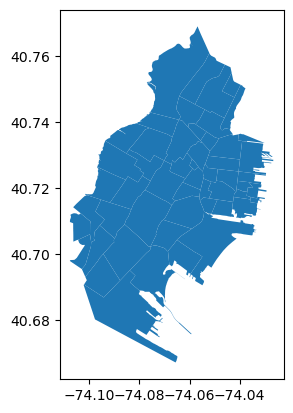

In [60]:
jersey_city.plot()

In [111]:
jersey_city['area_km'] = jersey_city['acres'] * 3280.84
jersey_city.head()

,cartodb_id,area_sq_ft,acres,area,neighborhood,color,lon,lat,geometry,area_km
0,38,411601381.8,9449.068,Greenville,Port Liberte,NaN,-74.074540,40.694202,"POLYGON ((-74.06862 40.70098, -74.06808 40.696...",3.100088e+07
1,52,411601381.8,9449.068,Bergen-Lafayette,LSP Industrial,NaN,-74.062358,40.699189,"POLYGON ((-74.06808 40.69684, -74.06862 40.700...",3.100088e+07
2,29,411601381.8,9449.068,West Side,Hackensack,NaN,-74.085147,40.735520,"POLYGON ((-74.07601 40.73822, -74.07781 40.737...",3.100088e+07
3,35,411601381.8,9449.068,Bergen-Lafayette,Lafayette,12.0,-74.061279,40.712676,"POLYGON ((-74.056 40.71735, -74.056 40.71692, ...",3.100088e+07
4,51,411601381.8,9449.068,Greenville,Jackson Hill,15.0,-74.085503,40.700791,"POLYGON ((-74.07561 40.70233, -74.0758 40.7020...",3.100088e+07


In [61]:
jersey_city.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 53 entries, 0 to 52
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   cartodb_id    53 non-null     int32   
 1   area_sq_ft    53 non-null     float64 
 2   acres         53 non-null     float64 
 3   area          53 non-null     str     
 4   neighborhood  53 non-null     str     
 5   color         18 non-null     float64 
 6   lon           53 non-null     float64 
 7   lat           53 non-null     float64 
 8   geometry      53 non-null     geometry
dtypes: float64(5), geometry(1), int32(1), str(2)
memory usage: 4.8 KB


In [62]:
jersey_city.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [63]:
jersey_city = jersey_city.to_crs('EPSG:4326')

#### station_departures

In [64]:
start_stations = citibike_df[
    [
        "ride_id",
        "start_station_id",
        "start_station_name",
        "start_lat",
        "start_lng"
    ]
].copy()

In [65]:
start_stations.head()

,ride_id,start_station_id,start_station_name,start_lat,start_lng
0,880A0159BA5275FB,JC019,Hilltop,40.731169,-74.057574
1,1A5E1E274B2AF0AD,JC019,Hilltop,40.731169,-74.057574
2,EA9928D3C05B8377,JC019,Hilltop,40.731169,-74.057574
3,3C42C367750B9292,JC019,Hilltop,40.731169,-74.057574
4,94D3B0265A7BDE1F,JC019,Hilltop,40.731169,-74.057574


In [66]:
start_stations = start_stations.rename(
    columns={
        "start_station_id": "station_id",
        "start_station_name": "station_name",
        "start_lat": "lat",
        "start_lng": "lng"
    }
)

start_stations["activity_type"] = "departure"

In [67]:
start_stations.head()

,ride_id,station_id,station_name,lat,lng,activity_type
0,880A0159BA5275FB,JC019,Hilltop,40.731169,-74.057574,departure
1,1A5E1E274B2AF0AD,JC019,Hilltop,40.731169,-74.057574,departure
2,EA9928D3C05B8377,JC019,Hilltop,40.731169,-74.057574,departure
3,3C42C367750B9292,JC019,Hilltop,40.731169,-74.057574,departure
4,94D3B0265A7BDE1F,JC019,Hilltop,40.731169,-74.057574,departure


#### station_arrivals

In [68]:
end_stations = citibike_df[
    [
        "ride_id",
        "end_station_id",
        "end_station_name",
        "end_lat",
        "end_lng"
    ]
].copy()

end_stations = end_stations.rename(
    columns={
        "end_station_id": "station_id",
        "end_station_name": "station_name",
        "end_lat": "lat",
        "end_lng": "lng"
    }
)

end_stations["activity_type"] = "arrival"

end_stations.head()

,ride_id,station_id,station_name,lat,lng,activity_type
0,880A0159BA5275FB,JC024,Pershing Field,40.742677,-74.051789,arrival
1,1A5E1E274B2AF0AD,JC063,Jackson Square,40.711130,-74.078900,arrival
2,EA9928D3C05B8377,HB101,Hoboken Terminal - Hudson St & Hudson Pl,40.735938,-74.030305,arrival
3,3C42C367750B9292,HB101,Hoboken Terminal - Hudson St & Hudson Pl,40.735938,-74.030305,arrival
4,94D3B0265A7BDE1F,HB101,Hoboken Terminal - Hudson St & Hudson Pl,40.735938,-74.030305,arrival


In [69]:
station_activity_long = pd.concat(
[    
    start_stations,
    end_stations
],
ignore_index=True
)

station_activity_long.head()

,ride_id,station_id,station_name,lat,lng,activity_type
0,880A0159BA5275FB,JC019,Hilltop,40.731169,-74.057574,departure
1,1A5E1E274B2AF0AD,JC019,Hilltop,40.731169,-74.057574,departure
2,EA9928D3C05B8377,JC019,Hilltop,40.731169,-74.057574,departure
3,3C42C367750B9292,JC019,Hilltop,40.731169,-74.057574,departure
4,94D3B0265A7BDE1F,JC019,Hilltop,40.731169,-74.057574,departure


In [70]:
station_activity_long['activity_type'].value_counts()

activity_type
departure    998281
arrival      998281
Name: count, dtype: int64

In [71]:
 station_activity_agg = (
     station_activity_long
     .groupby(
         [
             'station_id',
             'station_name',
             'lat',
             'lng',
             'activity_type'
         ],
         as_index=False
     )
     .agg(
         number_of_rides=('ride_id', 'count')
     ).sort_values(by = ['activity_type','number_of_rides'], ascending=False)
 )
 
 station_activity_agg.head()

,station_id,station_name,lat,lng,activity_type,number_of_rides
547,JC115,Grove St PATH,40.719410,-74.043090,departure,44984
377,HB101,Hoboken Terminal - Hudson St & Hudson Pl,40.735938,-74.030305,departure,25879
451,JC009,Hamilton Park,40.727596,-74.044247,departure,22232
385,HB106,River St & Newark St,40.736722,-74.029007,departure,21383
495,JC066,Newport PATH,40.727224,-74.033759,departure,20641


In [72]:
station_activity_agg.sort_values(by = ['activity_type','number_of_rides'], ascending=[True,False]).head()

,station_id,station_name,lat,lng,activity_type,number_of_rides
546,JC115,Grove St PATH,40.719410,-74.043090,arrival,47744
376,HB101,Hoboken Terminal - Hudson St & Hudson Pl,40.735938,-74.030305,arrival,26638
450,JC009,Hamilton Park,40.727596,-74.044247,arrival,22347
384,HB106,River St & Newark St,40.736722,-74.029007,arrival,22113
494,JC066,Newport PATH,40.727224,-74.033759,arrival,20698


In [73]:
jersey_city.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 53 entries, 0 to 52
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   cartodb_id    53 non-null     int32   
 1   area_sq_ft    53 non-null     float64 
 2   acres         53 non-null     float64 
 3   area          53 non-null     str     
 4   neighborhood  53 non-null     str     
 5   color         18 non-null     float64 
 6   lon           53 non-null     float64 
 7   lat           53 non-null     float64 
 8   geometry      53 non-null     geometry
dtypes: float64(5), geometry(1), int32(1), str(2)
memory usage: 4.8 KB


In [74]:
station_activity_agg.columns

Index(['station_id', 'station_name', 'lat', 'lng', 'activity_type',
       'number_of_rides'],
      dtype='str')

In [75]:
station_summary = station_activity_agg.pivot_table(
    index = [
        'station_id',
        'station_name',
        'lat',
        'lng'
    ],
    columns = 'activity_type',
    values = 'number_of_rides',
    fill_value=0
).reset_index()

station_summary.head()

activity_type,station_id,station_name,lat,lng,arrival,departure
0,3278.07,Brooklyn Ave & Snyder Ave,40.649150,-73.943680,1.0,0.0
1,3344.02,Park Circle & East Dr,40.651566,-73.972212,1.0,0.0
2,3480.04,Parkside Ave & Flatbush Ave,40.655630,-73.959680,1.0,0.0
3,3579.04,Windsor Pl & Howard Pl,40.659491,-73.980139,1.0,0.0
4,3762.08,10 St & 7 Ave,40.666208,-73.981999,1.0,0.0


In [76]:
station_summary = station_summary.rename(
    columns={
        "departure": "total_departures",
        "arrival": "total_arrivals"
    }
)

station_summary["total_activity"] = (
    station_summary["total_departures"] +
    station_summary["total_arrivals"]
)

station_summary["net_departures"] = (
    station_summary["total_departures"] -
    station_summary["total_arrivals"]
)

station_summary = station_summary.sort_values(
    "total_activity",
    ascending=False
).reset_index(drop=True)

station_summary.sort_values(by = 'net_departures', ascending=True).head()

activity_type,station_id,station_name,lat,lng,total_arrivals,total_departures,total_activity,net_departures
0,JC115,Grove St PATH,40.719410,-74.043090,47744.0,44984.0,92728.0,-2760.0
15,HB102,Hoboken Terminal - River St & Hudson Pl,40.736068,-74.029127,18073.0,16757.0,34830.0,-1316.0
1,HB101,Hoboken Terminal - Hudson St & Hudson Pl,40.735938,-74.030305,26638.0,25879.0,52517.0,-759.0
3,HB106,River St & Newark St,40.736722,-74.029007,22113.0,21383.0,43496.0,-730.0
96,5297.02,Vesey Pl & River Terrace,40.715338,-74.016584,469.0,0.0,469.0,-469.0


In [77]:
station_gdf = gpd.GeoDataFrame(
    station_summary,
    geometry=gpd.points_from_xy(
        station_summary['lng'],
        station_summary['lat']
    ),
    crs='EPSG:4326'
)

station_gdf.head()

activity_type,station_id,station_name,lat,lng,total_arrivals,total_departures,total_activity,net_departures,geometry
0,JC115,Grove St PATH,40.719410,-74.043090,47744.0,44984.0,92728.0,-2760.0,POINT (-74.04309 40.71941)
1,HB101,Hoboken Terminal - Hudson St & Hudson Pl,40.735938,-74.030305,26638.0,25879.0,52517.0,-759.0,POINT (-74.0303 40.73594)
2,JC009,Hamilton Park,40.727596,-74.044247,22347.0,22232.0,44579.0,-115.0,POINT (-74.04425 40.7276)
3,HB106,River St & Newark St,40.736722,-74.029007,22113.0,21383.0,43496.0,-730.0,POINT (-74.02901 40.73672)
4,JC066,Newport PATH,40.727224,-74.033759,20698.0,20641.0,41339.0,-57.0,POINT (-74.03376 40.72722)


<Axes: >

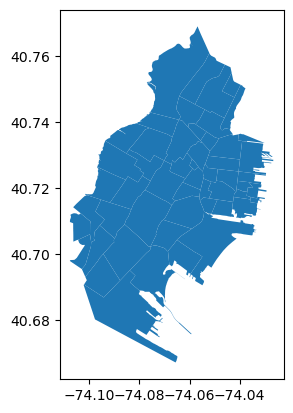

In [78]:
jersey_city.plot()

<Axes: >

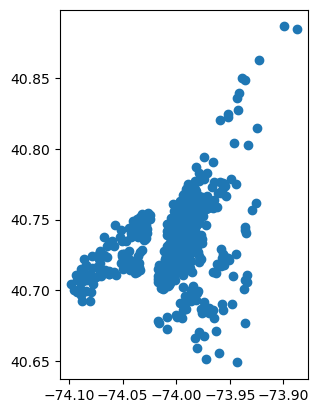

In [79]:
station_gdf.plot()

### Top Lines and Spatial Aggregation

#### Spatial Join:Assign Stations to Neighborhoods

In [80]:
station_neighborhood = gpd.sjoin(
    station_gdf,
    jersey_city,
    how='inner',
    predicate='within'
)

station_neighborhood.head()

,station_id,station_name,lat_left,lng,total_arrivals,total_departures,total_activity,net_departures,geometry,index_right,cartodb_id,area_sq_ft,acres,area,neighborhood,color,lon,lat_right
0,JC115,Grove St PATH,40.719410,-74.043090,47744.0,44984.0,92728.0,-2760.0,POINT (-74.04309 40.71941),49,2,411601381.8,9449.068,Downtown,Van Vorst Park,21.0,-74.047234,40.718943
2,JC009,Hamilton Park,40.727596,-74.044247,22347.0,22232.0,44579.0,-115.0,POINT (-74.04425 40.7276),10,18,411601381.8,9449.068,Downtown,Hamilton Park,28.0,-74.046672,40.727436
4,JC066,Newport PATH,40.727224,-74.033759,20698.0,20641.0,41339.0,-57.0,POINT (-74.03376 40.72722),8,12,411601381.8,9449.068,Downtown,Newport,22.0,-74.034927,40.729255
5,JC109,Bergen Ave & Sip Ave,40.731009,-74.064437,20357.0,20370.0,40727.0,13.0,POINT (-74.06444 40.73101),16,31,411601381.8,9449.068,Journal Square,Journal Square,NaN,-74.063466,40.733757
6,JC116,Exchange Pl,40.716366,-74.034344,20142.0,19982.0,40124.0,-160.0,POINT (-74.03434 40.71637),48,13,411601381.8,9449.068,Downtown,Exchange Place,23.0,-74.033539,40.716458


In [81]:
route_summary = (
    citibike_df
    .dropna(
        subset=[
            "start_station_id",
            "start_station_name",
            "end_station_id",
            "end_station_name",
            "start_lat",
            "start_lng",
            "end_lat",
            "end_lng"
        ]
    )
    .groupby(
        [
            "start_station_id",
            "start_station_name",
            "end_station_id",
            "end_station_name",
            "start_lat",
            "start_lng",
            "end_lat",
            "end_lng"
        ],
        as_index=False
    )
    .agg(
        number_of_rides=("ride_id", "count")
    )
    .sort_values("number_of_rides", ascending=False)
)

route_summary["route"] = (
    route_summary["start_station_name"] +
    " → " +
    route_summary["end_station_name"]
)

route_summary.head()

,start_station_id,start_station_name,end_station_id,end_station_name,start_lat,start_lng,end_lat,end_lng,number_of_rides,route
83,HB101,Hoboken Terminal - Hudson St & Hudson Pl,JC105,Hoboken Ave at Monmouth St,40.735938,-74.030305,40.735208,-74.046964,4559,Hoboken Terminal - Hudson St & Hudson Pl → Hob...
5583,JC055,McGinley Square,JC109,Bergen Ave & Sip Ave,40.725340,-74.067622,40.731009,-74.064437,4306,McGinley Square → Bergen Ave & Sip Ave
8709,JC115,Grove St PATH,JC013,Marin Light Rail,40.719410,-74.043090,40.714584,-74.042817,4131,Grove St PATH → Marin Light Rail
3937,JC013,Marin Light Rail,JC115,Grove St PATH,40.714584,-74.042817,40.719410,-74.043090,3831,Marin Light Rail → Grove St PATH
8723,JC115,Grove St PATH,JC052,Liberty Light Rail,40.719410,-74.043090,40.711242,-74.055701,3750,Grove St PATH → Liberty Light Rail


#### Instpect Top Routes

In [82]:
top_routes = route_summary.head(10)

top_routes[
    [
        'route',
        'number_of_rides'
    ]
]

,route,number_of_rides
83,Hoboken Terminal - Hudson St & Hudson Pl → Hob...,4559
5583,McGinley Square → Bergen Ave & Sip Ave,4306
8709,Grove St PATH → Marin Light Rail,4131
3937,Marin Light Rail → Grove St PATH,3831
8723,Grove St PATH → Liberty Light Rail,3750
8445,Bergen Ave & Sip Ave → McGinley Square,3609
5395,Liberty Light Rail → Grove St PATH,3605
8154,Hoboken Ave at Monmouth St → Hoboken Terminal ...,3257
4570,Brunswick St → Grove St PATH,3175
3788,Hamilton Park → Grove St PATH,2998


#### Drawing Top Lines with Folium

In [ ]:

import folium

top_lines = route_summary.head(100).copy()

center_lat = station_gdf['lat'].mean()
center_lng = station_gdf['lng'].mean()

line_map = folium.Map(
    location=[center_lat, center_lng],
    zoom_start=12
)

max_rides = top_lines['number_of_rides'].max()

for _, row in top_lines.iterrows():
    
    start_point = [
        row['start_lat'],
        row['start_lng']
    ]
    
    end_point = [
        row['end_lat'],
        row['end_lng']
    ]
    
    line_weight = 1 + (row['number_of_rides'] / max_rides) * 8
    
    folium.PolyLine(
        locations=[start_point, end_point],
        weight=line_weight,
        opacity=0.5,
        popup=f"""
        <b>{row['route']}</b><br>
        Number of Rides: {row['number_of_rides']}
        """
    ).add_to(line_map)
    


In [126]:
line_map

#### Top 5 Rides

In [ ]:
top_5_lines = route_summary.head(5).copy()

center_lat = station_gdf['lat'].mean()
center_lng = station_gdf['lng'].mean()

line_color_map = folium.Map(
    location=[center_lat, center_lng],
    zoom_start=12
)

max_rides = top_5_lines['number_of_rides'].max()

for _, row in top_5_lines.iterrows():
    
    start_point = [
        row['start_lat'],
        row['start_lng']
    ]
    
    end_point = [
        row['end_lat'],
        row['end_lng']
    ]
    
    line_weight = 1 + (row['number_of_rides'] / max_rides) * 8
    
    folium.PolyLine(
        locations=[start_point, end_point],
        weight=line_weight,
        color='darkblue',
        opacity=0.9,
        popup=f"""
        <b>{row['route']}</b><br>
        Number of Rides: {row['number_of_rides']}
        """
    ).add_to(line_color_map)
    

In [124]:
line_color_map

In [85]:
print(station_gdf.shape)
print(station_neighborhood.shape)

(488, 9)
(79, 18)


### Neighborhood-Level Summary

In [86]:
neighborhood_activity = (
    station_neighborhood
    .groupby('neighborhood', as_index=False)
    .agg(
        number_of_stations=('station_id', 'nunique'),
        total_departures=("total_departures", "sum"),
        total_arrivals=("total_arrivals", "sum"),
        total_activity=("total_activity", "sum"),
        net_departures=("net_departures", "sum")
    )
)

neighborhood_activity['avg_activity_per_station'] = (
    neighborhood_activity['total_activity'] /
    neighborhood_activity['number_of_stations']
)

neighborhood_activity = neighborhood_activity.sort_values(
    'total_activity',
    ascending=False
)

neighborhood_activity.head()

,neighborhood,number_of_stations,total_departures,total_arrivals,total_activity,net_departures,avg_activity_per_station
25,Van Vorst Park,6,96144.0,98853.0,194997.0,-2709.0,32499.500000
17,Palus Hook,6,59496.0,59160.0,118656.0,336.0,19776.000000
14,Newport,2,39350.0,39402.0,78752.0,-52.0,39376.000000
10,Journal Square,3,32970.0,32560.0,65530.0,410.0,21843.333333
4,Hamilton Park,2,31729.0,31922.0,63651.0,-193.0,31825.500000


#### Visualize Each Station as a Point


In [87]:
center_lat = station_gdf.geometry.y.mean()
center_lng = station_gdf.geometry.x.mean()

center_lat, center_lng

(np.float64(40.734012258630905), np.float64(-74.00137516113631))

In [88]:
station_point_map = folium.Map(
    locations=[center_lat, center_lng],
    zoom_start=12
)

for _, row in station_gdf.iterrows():

    folium.CircleMarker(
        location=[
            row.geometry.y,
            row.geometry.x
        ],
        radius=5,
        popup=f"""
        <b>{row['station_name']}</b><br>
        Station ID: {row['station_id']}<br>
        Departures: {row['total_departures']:.0f}<br>
        Arrivals: {row['total_arrivals']:.0f}<br>
        Total Activity: {row['total_activity']:.0f}<br>
        Net Departures: {row['net_departures']:.0f}
        """,
        tooltip=row["station_name"],
        fill=True,
        fill_opacity=0.6,
        opacity=0.8
    ).add_to(station_point_map)

station_point_map

#### Merge Neighborhood Metrics Back to Polygons

In [89]:
neighborhood_choropleth_gdf = jersey_city.merge(
    neighborhood_activity,
    on='neighborhood',
    how='left'
)

neighborhood_choropleth_gdf.head()

,cartodb_id,area_sq_ft,acres,area,neighborhood,color,lon,lat,geometry,number_of_stations,total_departures,total_arrivals,total_activity,net_departures,avg_activity_per_station
0,38,411601381.8,9449.068,Greenville,Port Liberte,NaN,-74.074540,40.694202,"POLYGON ((-74.06862 40.70098, -74.06808 40.696...",1.0,12.0,9.0,21.0,3.0,21.0000
1,52,411601381.8,9449.068,Bergen-Lafayette,LSP Industrial,NaN,-74.062358,40.699189,"POLYGON ((-74.06808 40.69684, -74.06862 40.700...",NaN,NaN,NaN,NaN,NaN,NaN
2,29,411601381.8,9449.068,West Side,Hackensack,NaN,-74.085147,40.735520,"POLYGON ((-74.07601 40.73822, -74.07781 40.737...",NaN,NaN,NaN,NaN,NaN,NaN
3,35,411601381.8,9449.068,Bergen-Lafayette,Lafayette,12.0,-74.061279,40.712676,"POLYGON ((-74.056 40.71735, -74.056 40.71692, ...",6.0,30845.0,30730.0,61575.0,115.0,10262.5000
4,51,411601381.8,9449.068,Greenville,Jackson Hill,15.0,-74.085503,40.700791,"POLYGON ((-74.07561 40.70233, -74.0758 40.7020...",16.0,6142.0,6045.0,12187.0,97.0,761.6875


In [127]:
activity_columns = [
    "number_of_stations",
    "total_departures",
    "total_arrivals",
    "total_activity",
    "net_departures",
    "avg_activity_per_station"
]

neighborhood_choropleth_gdf[activity_columns] = (
    neighborhood_choropleth_gdf[activity_columns]
    .fillna(0)
)

neighborhood_choropleth_gdf[
    [
        'neighborhood',
        "number_of_stations",
        "total_departures",
        "total_arrivals",
        "total_activity",
        "avg_activity_per_station"
    ]
].head()

,neighborhood,number_of_stations,total_departures,total_arrivals,total_activity,avg_activity_per_station
0,Port Liberte,1.0,12.0,9.0,21.0,21.0000
1,LSP Industrial,0.0,0.0,0.0,0.0,0.0000
2,Hackensack,0.0,0.0,0.0,0.0,0.0000
3,Lafayette,6.0,30845.0,30730.0,61575.0,10262.5000
4,Jackson Hill,16.0,6142.0,6045.0,12187.0,761.6875


### Choropleth Map

#### Helper Function for Folium Choropleth

In [128]:
def create_neighborhood_choropleth(
    gdf,
    metric,
    legend_name,
    neighborhood_col='neighborhood'
):
    choropleth_map = folium.Map(
        location=[center_lat, center_lng],
        zoom_start=12
    )
    
    folium.Choropleth(
        geo_data=gdf,
        data=gdf,
        columns=[neighborhood_col, metric],
        key_on=f"feature.properties.{neighborhood_col}",
        foll_opacity=0.7,
        line_opacity=0.4,
        legend_name=legend_name,
        nan_fill_opacity=0.1
    ).add_to(choropleth_map)
    
    folium.GeoJson(
        gdf,
        name='Neighborhood Boundaries',
        tooltip=folium.GeoJsonTooltip(
            fields=[
                neighborhood_col,
                metric
            ],
            localize=True
        ),
        style_function=lambda feature: {
            'fillOpacity': 0,
            'color': 'blacl',
            'weight': 1
        }
    ).add_to(choropleth_map)
    
    folium.LayerControl().add_to(choropleth_map)
    
    return choropleth_map

#### Choropleth: Total Activity by Neighborhood

In [132]:
total_activity_map = create_neighborhood_choropleth(
    gdf=neighborhood_choropleth_gdf,
    metric='total_activity',
    legend_name='Total Citi Bike Activity',
    neighborhood_col='neighborhood'
)

total_activity_map

#### Choropleth by Number of Stations

In [133]:
station_count_map = create_neighborhood_choropleth(
    gdf=neighborhood_choropleth_gdf,
    metric="number_of_stations",
    legend_name="Number of Citi Bike Stations",
    neighborhood_col="neighborhood"
)

station_count_map

#### Choropleth by Average Activity per Station

In [134]:
avg_activity_map = create_neighborhood_choropleth(
    gdf=neighborhood_choropleth_gdf,
    metric="avg_activity_per_station",
    legend_name="Average Activity per Station",
    neighborhood_col="neighborhood"
)

avg_activity_map

#### Choropleth by Total Departures

In [135]:
departures_map = create_neighborhood_choropleth(
    gdf=neighborhood_choropleth_gdf,
    metric="total_departures",
    legend_name="Total Departures",
    neighborhood_col="neighborhood"
)

departures_map

#### Choropleth by Total Arrivals

In [136]:
arrivals_map = create_neighborhood_choropleth(
    gdf=neighborhood_choropleth_gdf,
    metric="total_arrivals",
    legend_name="Total Arrivals",
    neighborhood_col="neighborhood"
)

arrivals_map